![fdv](kolmogorov.png)


1. Пусть Xi ∼ N (0, 1).
1) Построить эмпирическую функцию распределения (ЭФР) на одном графике с теоретической
функцией распределения при разных n (проиллюстрировать сходимость ЭФР к ф.р.). То же для
Xi ∼ R[0, 1], Xi ∼ Bin(m, p), где m = 3, m = 10.

2) Построить 95% доверительную полосу для ф.р., используя а) критерий Колмогорова. б) нера-
венство Дворецкого-Кифера-Вольфовица.

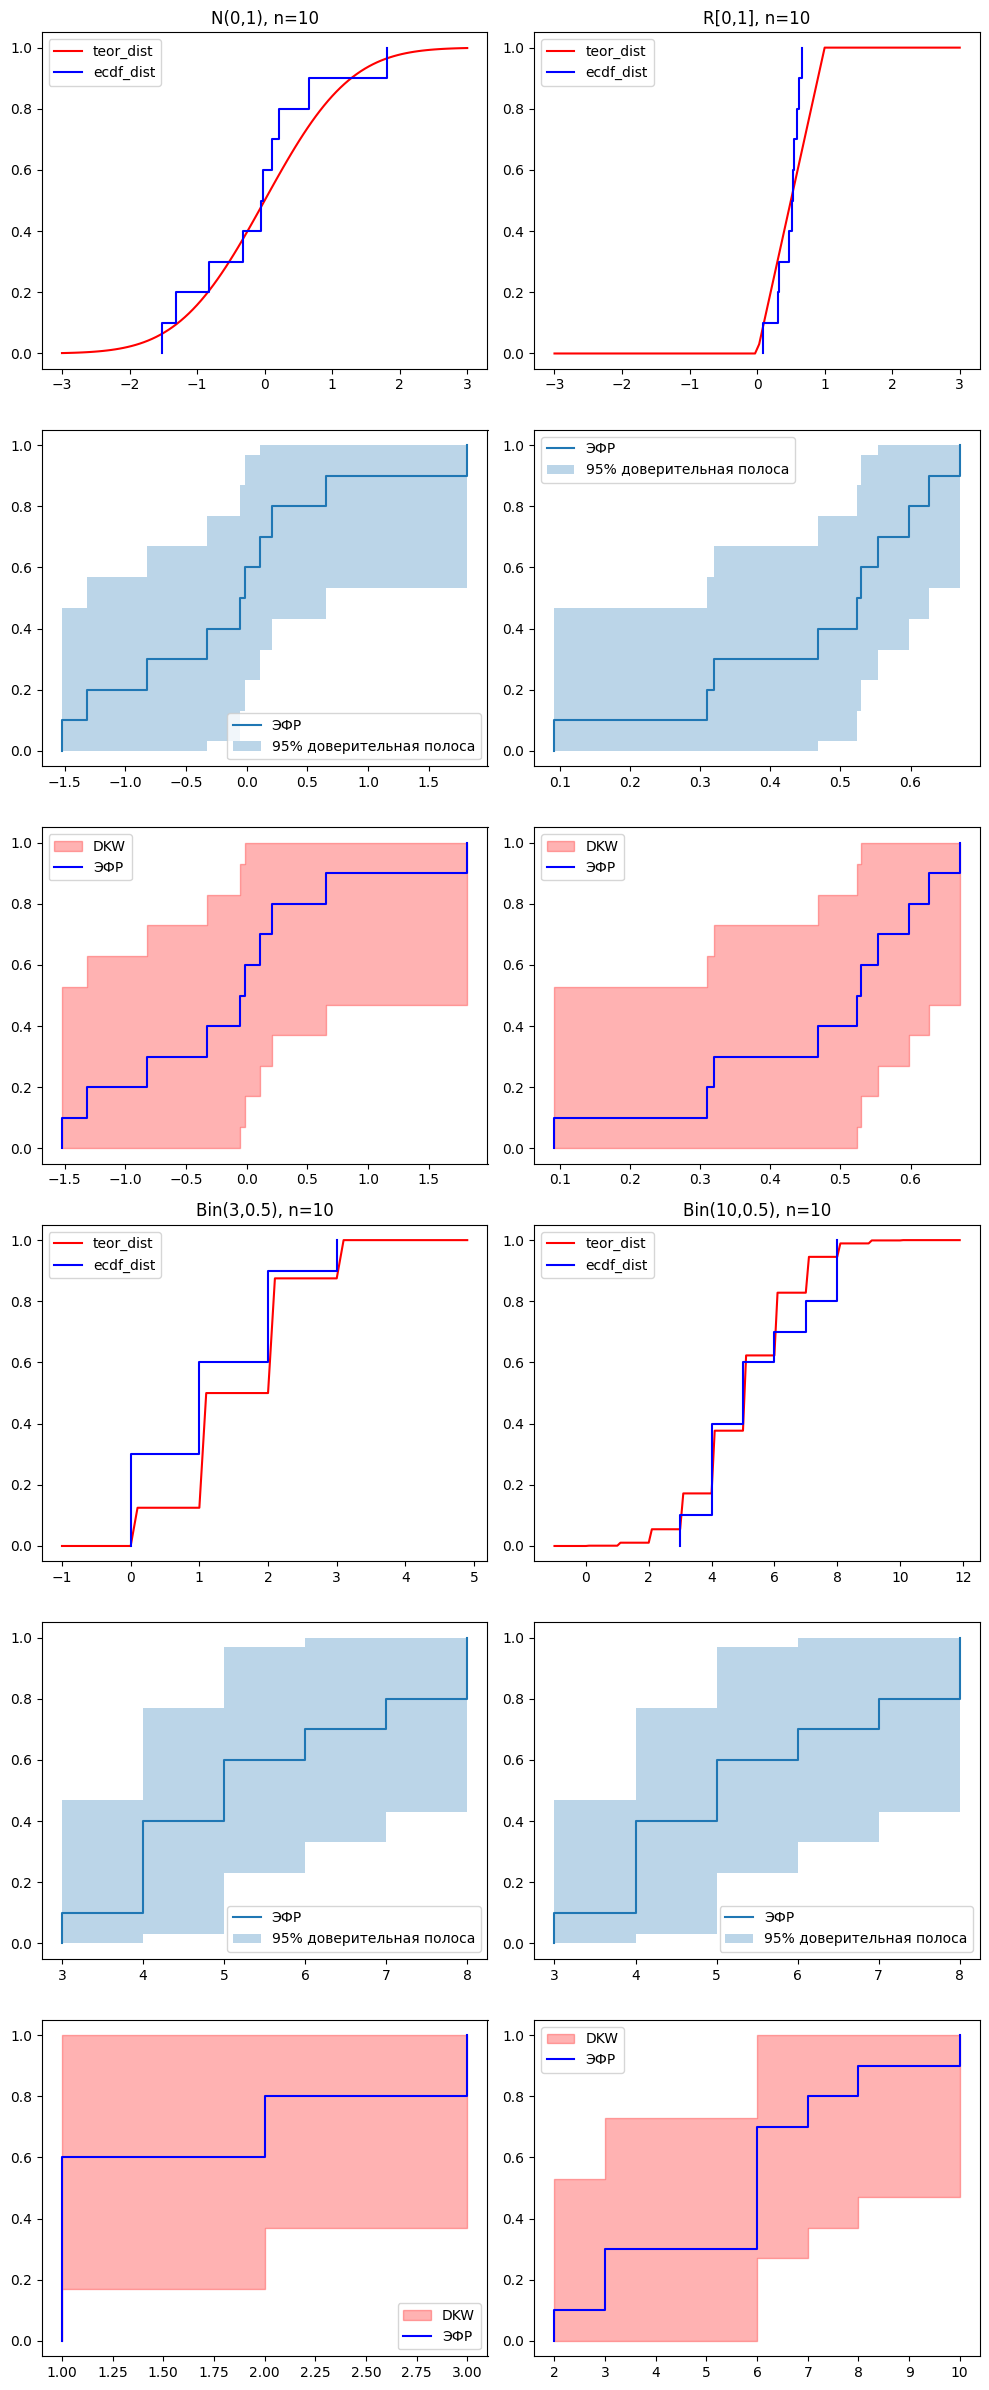

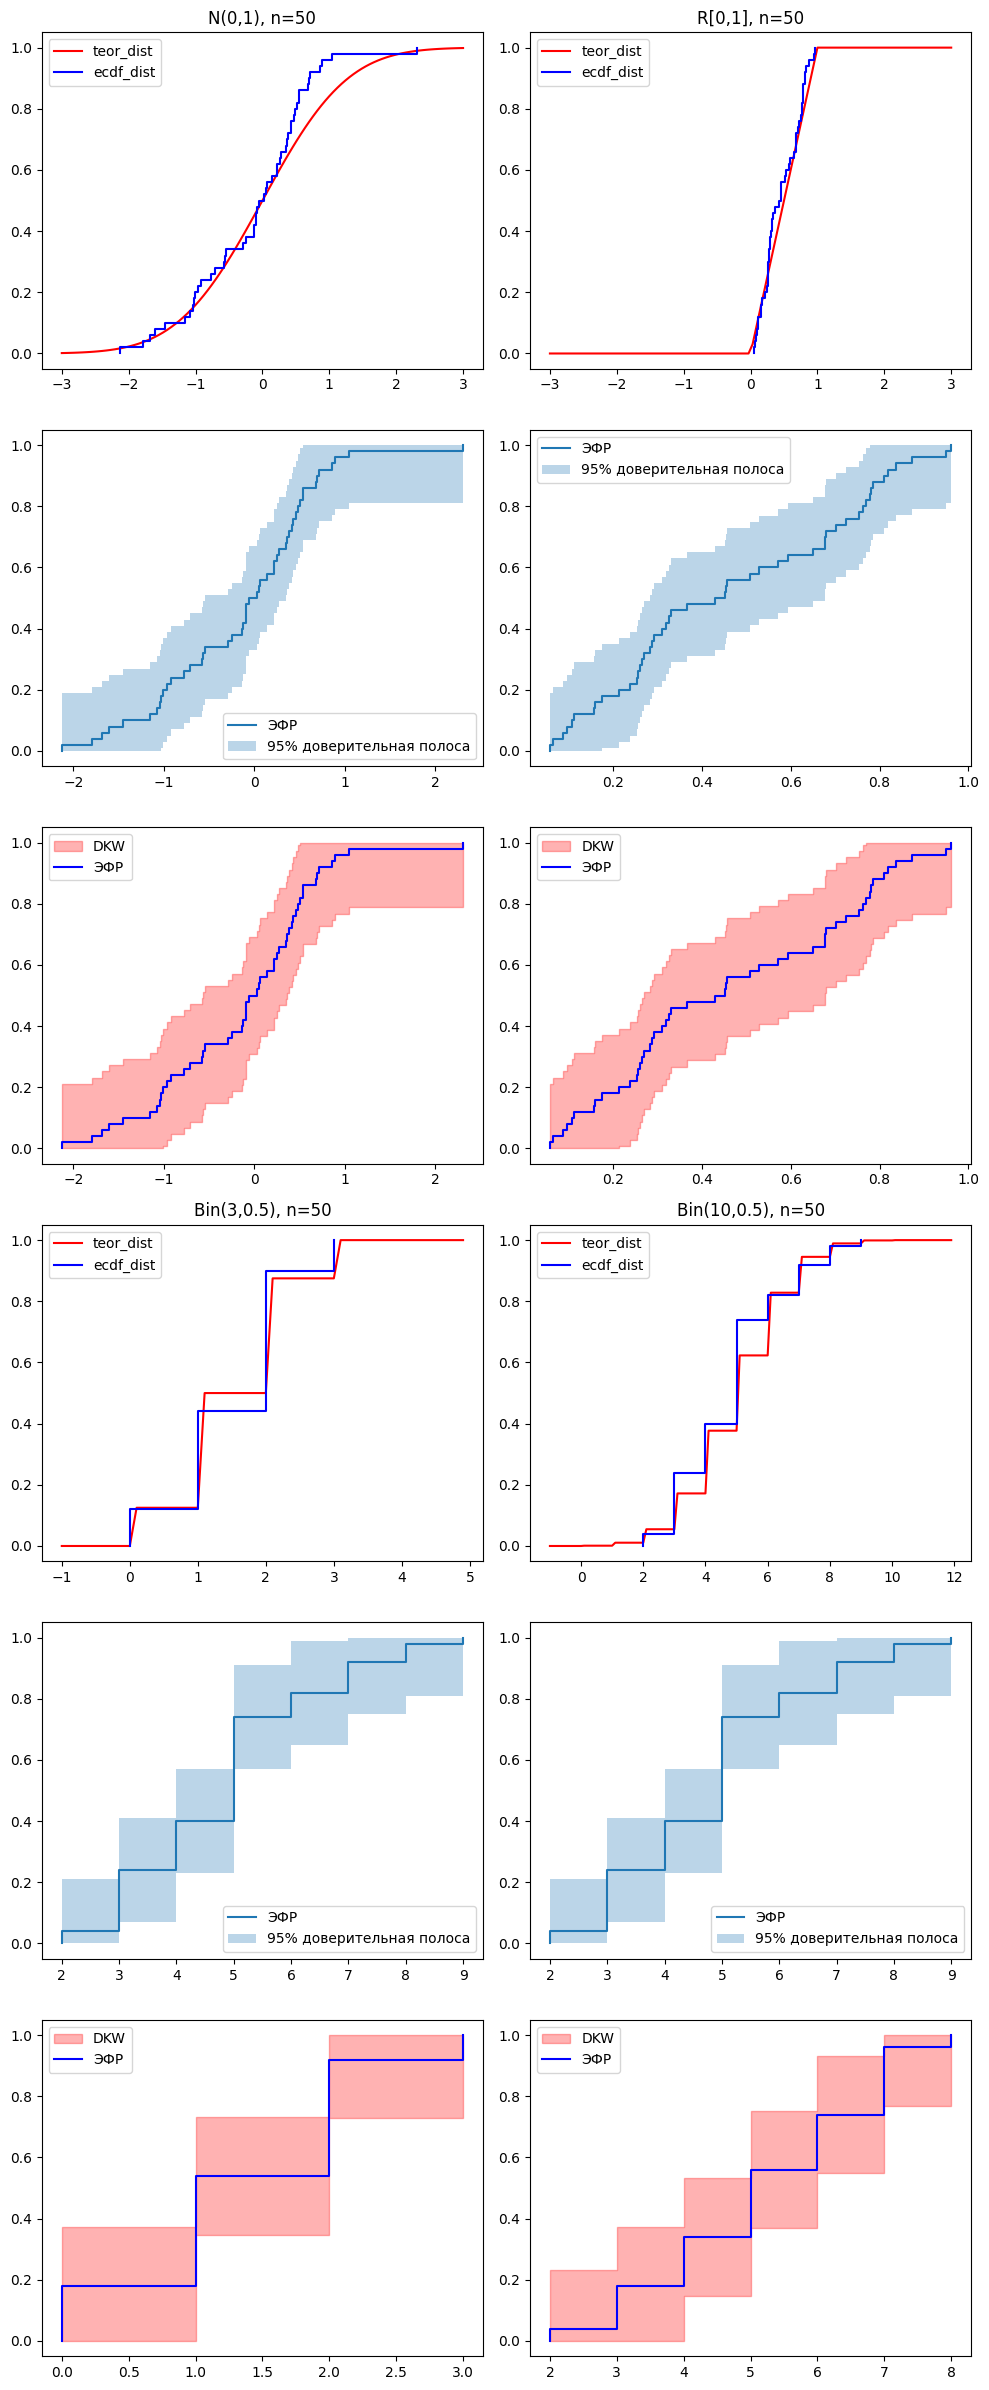

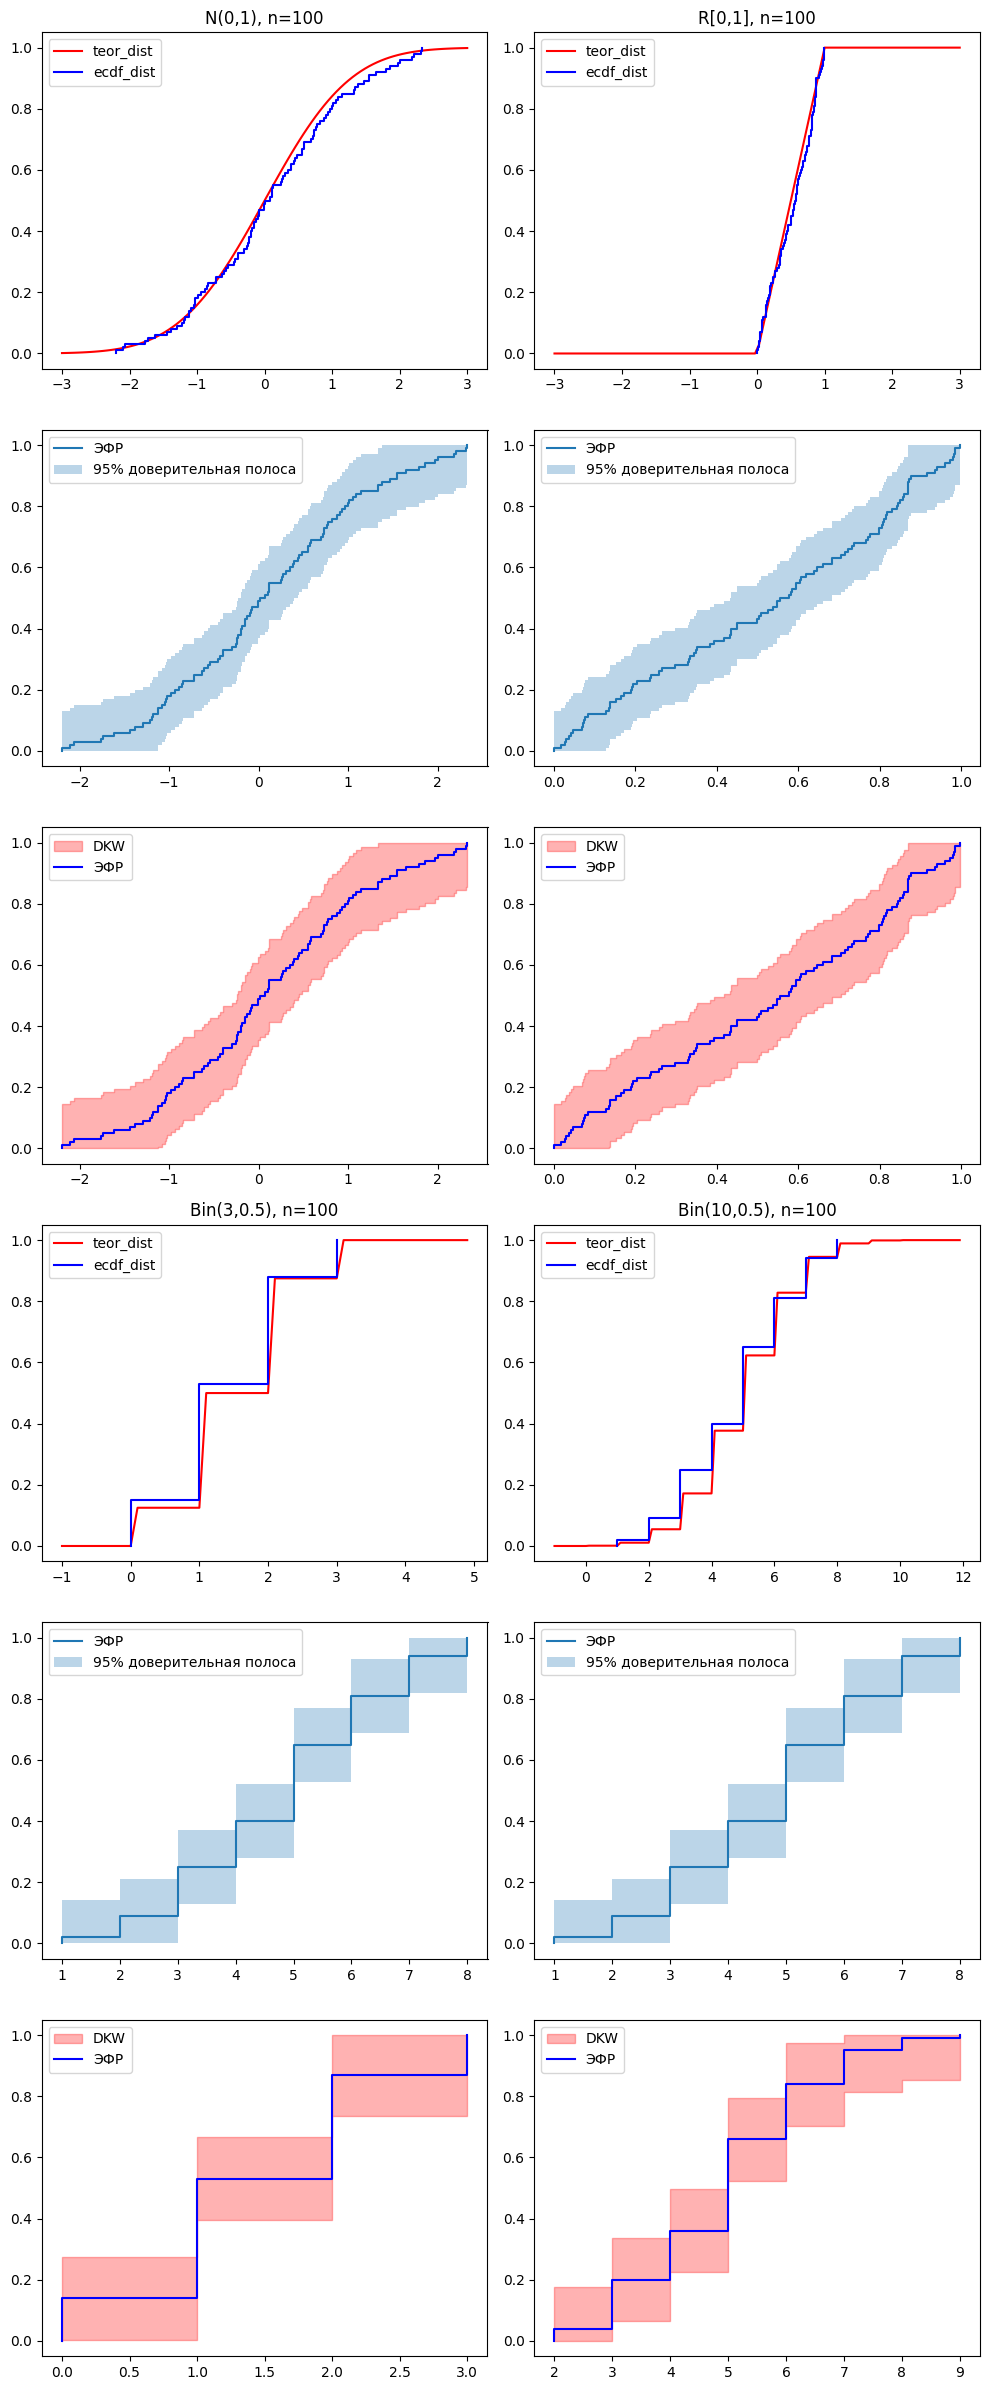

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF


def bild_empirical_distribution_func(n_values, p, m_values):
    x = np.linspace(-3, 3, 100)
    for n in n_values:
        plt.figure(figsize=(10, 24))
        sample_norm = np.random.normal(0, 1, n)
        theor_dist_norm = stats.norm.cdf(x, 0, 1)
        ecdf_norm = ECDF(sample_norm)
        plt.subplot(6, 2, 1)
        plt.plot(x, theor_dist_norm, color = 'red', label = 'teor_dist')
        plt.step(ecdf_norm.x, ecdf_norm.y, where='post', color = 'blue', label = 'ecdf_dist')
        plt.title(f'N(0,1), n={n}')
        plt.legend()
        sample_un = np.random.uniform(0, 1, n)
        theor_dist_un = stats.uniform.cdf(x, 0, 1)
        ecdf_un = ECDF(sample_un)
        plt.subplot(6, 2, 2)
        plt.plot(x, theor_dist_un, color = 'red', label = 'teor_dist')
        plt.step(ecdf_un.x, ecdf_un.y, where='post', color = 'blue', label = 'ecdf_dist')    
        plt.title(f'R[0,1], n={n}') 
        plt.legend()  
        
        plt.subplot(6, 2, 3)
        bild_confidence_zone_with_kolmogorov(alpha, sample_norm, n, ecdf_norm)
        
        plt.subplot(6, 2, 4)
        bild_confidence_zone_with_kolmogorov(alpha, sample_un, n, ecdf_un)
        
        plt.subplot(6, 2, 5)
        bild_confidence_zone_with_DKW_inequality(alpha, n, ecdf_norm)
        
        plt.subplot(6, 2, 6)
        bild_confidence_zone_with_DKW_inequality(alpha, n, ecdf_un)
        for i, m in enumerate(m_values):
            plt.subplot(6, 2, i+7)
            x_bin = np.arange(-1, m+2, 0.1)
            def bild_for_binom(m, p):
                sample_bin = np.random.binomial(m, p, n)
                theor_dist_bin = stats.binom.cdf(x_bin, m, p)
                return sample_bin, theor_dist_bin
            sample_bin, theor_dist_bin = bild_for_binom(m, p)
            ecdf_bin = ECDF(sample_bin)
            plt.plot(x_bin, theor_dist_bin, color = 'red', label = 'teor_dist')
            plt.step(ecdf_bin.x, ecdf_bin.y, where='post', color = 'blue', label = 'ecdf_dist')
            plt.title(f'Bin({m},{p}), n={n}')
            plt.legend()
                
        for i, m in enumerate(m_values):
            plt.subplot(6, 2, 9+i)
            sample_bin, _ = bild_for_binom(m, p)
            bild_confidence_zone_with_kolmogorov(alpha, sample_bin, n, ecdf_bin)
        
        for i, m in enumerate(m_values):
            plt.subplot(6, 2, 11+i)
            sample_bin, _ = bild_for_binom(m, p)
            ecdf_bin = ECDF(sample_bin)
            bild_confidence_zone_with_DKW_inequality(alpha, n, ecdf_bin)
        
        plt.tight_layout()
        plt.show()

#Теперь построим 95% доверительную полосу для ф.р., используя а) критерий Колмогорова
def bild_confidence_zone_with_kolmogorov(alpha, sample, n, ecdf):            #ISF = Inverse Survival Function 
    x_unique = ecdf.x  # это отсортированные уникальные значения
    y_ecdf = ecdf.y    # это значения ЭФР (уже правильно посчитанные)
    d_alpha = stats.ksone.isf(alpha, n) #d, такое что P(D_n > d) = alpha, D_n - статистика Колмогорова, т.е. sup|F_n - F| по x
    lower = np.maximum(0, y_ecdf - d_alpha)
    upper = np.minimum(1, y_ecdf + d_alpha)
    plt.step(x_unique, y_ecdf, where='post', label='ЭФР')
    plt.fill_between(x_unique, lower, upper, step='post', alpha=0.3, label='95% доверительная полоса')
    plt.legend()

def bild_confidence_zone_with_DKW_inequality(alpha, n, ecdf):
    x_unique = ecdf.x  
    y_ecdf = ecdf.y    
    epsilon = np.sqrt(-np.log(alpha/2) / (2 * n))
    lower = np.maximum(0, y_ecdf - epsilon)
    upper = np.minimum(1, y_ecdf + epsilon)
    plt.fill_between(x_unique, lower, upper, step='post', alpha=0.3, color = 'red', label=f'DKW')
    plt.step(x_unique, y_ecdf, where='post', color='blue', label='ЭФР')
    plt.legend()


n_values = [10, 50, 100]
m_values = np.array([3, 10])  
p = 0.5
alpha = 0.05
bild_empirical_distribution_func(n_values, p, m_values)    

2. С помощью критерия Колмогорова проверить гипотезу H0 : Xi ∼ N (0, 1), если
Xi = (Yi − EYi)/√DYi, где

(a) Yi ∼ N (−3, 8),

(b) Yi ∼ Bin(m, 1/2),

(c) Yi имеют распределение Ирвина–Холла (сумма m независимых равномерных с.в.).

Построить графики p-value для m = 1, 2, 5, 20. Рассмотреть выборки длины n = 50, 100, 500.

Для N(-3, 8, 50) гипотезу отвергаем, т.к. статистика Колмогорова 0.38290292204272813 > 0.16959440647022855 - критическое значение
Для Bin(1, 0.5, 50) гипотезу отвергаем, т.к. p-value статистики Колмогорова 1.7179957585381783e-09 < 0.05
Для Irwin–Hall(1, 50) гипотезу отвергаем, т.к. p-value статистики Колмогорова 0.008831784889570926 < 0.05
Для Bin(2, 0.5, 50) гипотезу отвергаем, т.к. p-value статистики Колмогорова 2.6019636855580366e-07 < 0.05
Для Irwin–Hall(2, 50) гипотезу принимаем, т.к. p-value статистики Колмогорова 0.8813326578982861 > 0.05 - критическое значение
Для Bin(5, 0.5, 50) гипотезу отвергаем, т.к. p-value статистики Колмогорова 6.27957197934654e-05 < 0.05
Для Irwin–Hall(5, 50) гипотезу отвергаем, т.к. p-value статистики Колмогорова 0.016277492683045902 < 0.05
Для Bin(20, 0.5, 50) гипотезу отвергаем, т.к. p-value статистики Колмогорова 0.04953191774789245 < 0.05
Для Irwin–Hall(20, 50) гипотезу принимаем, т.к. p-value статистики Колмогорова 0.32945823818719244 > 0.05 - кри

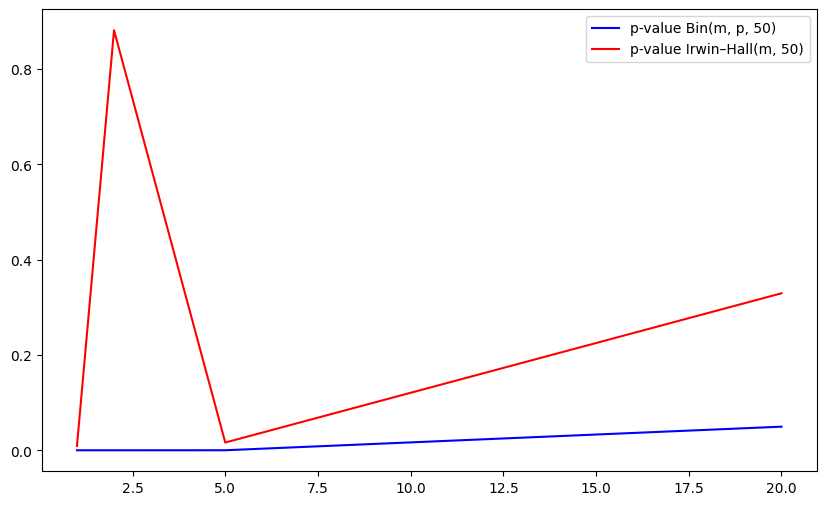

Для N(-3, 8, 100) гипотезу отвергаем, т.к. статистика Колмогорова 0.3010176217893913 > 0.12066568772965514 - критическое значение
Для Bin(1, 0.5, 100) гипотезу отвергаем, т.к. p-value статистики Колмогорова 6.786012387557686e-20 < 0.05
Для Irwin–Hall(1, 100) гипотезу отвергаем, т.к. p-value статистики Колмогорова 0.026805076518993554 < 0.05
Для Bin(2, 0.5, 100) гипотезу отвергаем, т.к. p-value статистики Колмогорова 1.4599711628693083e-16 < 0.05
Для Irwin–Hall(2, 100) гипотезу принимаем, т.к. p-value статистики Колмогорова 0.436098349558779 > 0.05 - критическое значение
Для Bin(5, 0.5, 100) гипотезу отвергаем, т.к. p-value статистики Колмогорова 6.192147625877922e-13 < 0.05
Для Irwin–Hall(5, 100) гипотезу принимаем, т.к. p-value статистики Колмогорова 0.6605061709201835 > 0.05 - критическое значение
Для Bin(20, 0.5, 100) гипотезу отвергаем, т.к. p-value статистики Колмогорова 2.5302709704075865e-05 < 0.05
Для Irwin–Hall(20, 100) гипотезу принимаем, т.к. p-value статистики Колмогорова 0

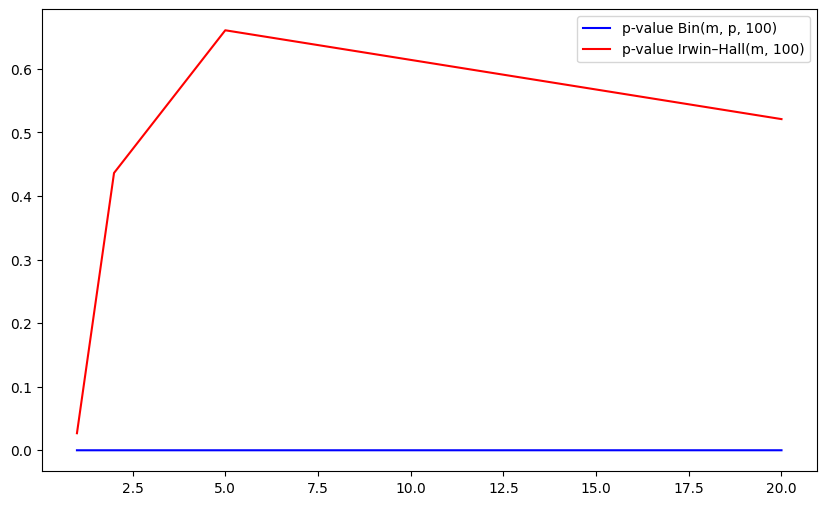

Для N(-3, 8, 500) гипотезу отвергаем, т.к. статистика Колмогорова 0.2359416071093311 > 0.0543949663107442 - критическое значение
Для Bin(1, 0.5, 500) гипотезу отвергаем, т.к. p-value статистики Колмогорова 1.7533210509450823e-107 < 0.05
Для Irwin–Hall(1, 500) гипотезу отвергаем, т.к. p-value статистики Колмогорова 0.0005295173504706303 < 0.05
Для Bin(2, 0.5, 500) гипотезу отвергаем, т.к. p-value статистики Колмогорова 2.8678296032001965e-99 < 0.05
Для Irwin–Hall(2, 500) гипотезу принимаем, т.к. p-value статистики Колмогорова 0.27110487427907837 > 0.05 - критическое значение
Для Bin(5, 0.5, 500) гипотезу отвергаем, т.к. p-value статистики Колмогорова 4.053180514472984e-77 < 0.05
Для Irwin–Hall(5, 500) гипотезу принимаем, т.к. p-value статистики Колмогорова 0.8844282213572519 > 0.05 - критическое значение
Для Bin(20, 0.5, 500) гипотезу отвергаем, т.к. p-value статистики Колмогорова 1.3067955261813326e-58 < 0.05
Для Irwin–Hall(20, 500) гипотезу принимаем, т.к. p-value статистики Колмогоро

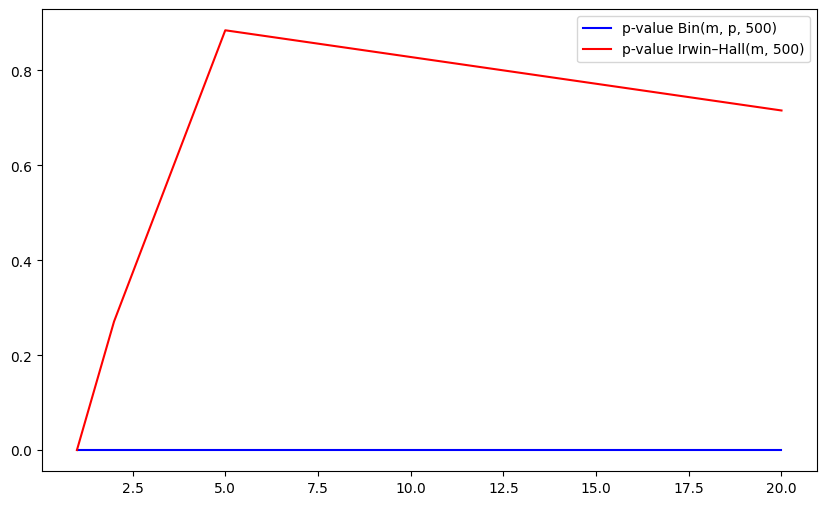

In [43]:
def kormogorov_test(n_values, alpha, m_values, p):
    for n in n_values:
        y_sample_norm = np.random.normal(-3, 8, n)
        x_sample_a = (y_sample_norm + 3) / np.sqrt(8)
        d_alpha = stats.ksone.isf(alpha, n)
        result_norm = stats.kstest(x_sample_a, 'norm', args=(0, 1))
        if result_norm.statistic > d_alpha:
            print(f"Для N(-3, 8, {n}) гипотезу отвергаем, т.к. статистика Колмогорова {result_norm.statistic} > {d_alpha} - критическое значение")
        else:
            print(f"Для N(-3, 8, {n}) гипотезу принимаем, т.к. статистика Колмогорова {result_norm.statistic} < {d_alpha} - критическое значение")
        pvalue_values_bin = []
        pvalue_values_ih = []
        for m in m_values:
            y_sample_bin = np.random.binomial(m, p, n)
            x_sample_b = (y_sample_bin - (m * p)) / np.sqrt(n * p * (1 - p))
            result_bin = stats.kstest(x_sample_b, 'norm', args=(0, 1))
            pvalue_values_bin.append(result_bin.pvalue)
            if result_bin.pvalue > alpha:  # p-value = P(D_n > D_observed) = 1 - F(D_observed)
                print(f"Для Bin({m}, {p}, {n}) гипотезу принимаем, т.к. p-value статистики Колмогорова {result_bin.pvalue} > {alpha} - критическое значение")
            else:
                print(f"Для Bin({m}, {p}, {n}) гипотезу отвергаем, т.к. p-value статистики Колмогорова {result_bin.pvalue} < {alpha}")
            y_sample_ih = np.random.uniform(0, 1, (n, m)).sum(axis=1) #Ирвин-Холл
            x_sample_c = (y_sample_ih - m / 2) / np.sqrt(m / 12)
            result_ih = stats.kstest(x_sample_c, 'norm', args=(0, 1))
            pvalue_values_ih.append(result_ih.pvalue)
            if result_ih.pvalue > alpha:  
                print(f"Для Irwin–Hall({m}, {n}) гипотезу принимаем, т.к. p-value статистики Колмогорова {result_ih.pvalue} > {alpha} - критическое значение")
            else:
                print(f"Для Irwin–Hall({m}, {n}) гипотезу отвергаем, т.к. p-value статистики Колмогорова {result_ih.pvalue} < {alpha}")
        plt.figure(figsize=(10, 6))
        plt.plot(m_values, pvalue_values_bin, color = 'blue', label = f'p-value Bin(m, p, {n})')
        plt.plot(m_values, pvalue_values_ih, color = 'red', label = f'p-value Irwin–Hall(m, {n})')
        plt.legend()
        plt.show()


n_values = [50, 100, 500]
alpha = 0.05
m_values = [1, 2, 5, 20]
p = 1/2
kormogorov_test(n_values, alpha, m_values, p)

3. Если выборка имеет нормальное распределение с неизвестными параметрами, то можно попробовать перейти от выборки Xi 

к (Xi−X)/S и применить к ним критерий Колмогорова нормальности N(0, 1). 

Построить график p-value при верной гипотезе и посмотреть корректно ли работает ”модифицированный” критерий.

In [ ]:
#Xi ~ N(a,b), a,b - не знаем
def mod_kormogorov_test(a, b, n, alpha, N_sim):
    pvalue_values = []
    for i in range(N_sim):
        sample = np.random.normal(a, b, n)
        y_sample = (sample - np.mean(sample)) / np.sqrt(np.var(sample))
        result = stats.kstest(y_sample, 'norm', args=(0, 1))
        pvalue_values.append(result.pvalue)
            
    